# Looking at eigenvalue scalings and eigenvectors
Understand the eigenvalues and eigenvectors of the matrix A
in finite-difference spatial discretizations of PDEs

Focus on the periodic case, where A is a **circulant** matrix (more specific than just Toeplitz).

## Advection only, periodic BCs

In [74]:
using LinearAlgebra
using Plots
using DifferentialEquations

# Set up grid
xL = -1.0
xR =  1.0
Nx = 30                    # number of points
x = range(xL, xR, length=Nx)

# Calculate cell size
dx = x[2] - x[1]

# Set velocity
a = 2.0

# Allocate stiffness matrix
A = zeros(Nx - 1, Nx - 1)

# Equation: u_t + a u_x = 0, with periodic BCs
# semi-discrete: u_t(x_i) = -a/2Δx ( u_{i+1} - u_{i-1} )

# Construct A except for first and last row
for i in 2:(Nx - 2)
    A[i, i - 1] =  a / (2dx)
    A[i, i + 1] = -a / (2dx)
end

# Periodic BCs
A[1,    2]    = -a / (2dx)
A[1,    Nx-1] =  a / (2dx)
A[Nx-1, 1]    = -a / (2dx)
A[Nx-1, Nx-2] =  a / (2dx)


display(A)

# Calculate eigenvalues of A
F = eigen(A);

λ = F.values;      # eigenvalues
V = F.vectors;     # columns are eigenvectors

perm = sortperm(abs.(imag.(λ))); # sorts in increasing order

λs = λ[perm]
Vs = V[:,perm];

29×29 Matrix{Float64}:
   0.0  -14.5    0.0    0.0    0.0  …    0.0    0.0    0.0    0.0   14.5
  14.5    0.0  -14.5    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0   14.5    0.0  -14.5    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0   14.5    0.0  -14.5       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0   14.5    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0   14.5  …    0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0  …    0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   0.0    0.0    0.0    0.0    0.0       0.0    0.0    0.0    0.0    0.0
   ⋮                        

In [75]:
λs

29-element Vector{ComplexF64}:
    4.808434892151162e-16 + 0.0im
  -3.7591520146530315e-16 - 3.135451534294311im
  -3.7591520146530315e-16 + 3.135451534294311im
   4.1083350478214045e-16 - 6.234142766119695im
   4.1083350478214045e-16 + 6.234142766119695im
  -3.8818545841992244e-16 - 9.259744373943427im
  -3.8818545841992244e-16 + 9.259744373943427im
    3.117137726944343e-16 - 12.176783945247681im
    3.117137726944343e-16 + 12.176783945247681im
   -1.458519205748705e-62 - 14.951061858133626im
   -1.458519205748705e-62 + 14.951061858133626im
   3.8374316727460895e-16 - 17.55005224061919im
   3.8374316727460895e-16 + 17.55005224061919im
                          ⋮
    2.338270124607234e-15 - 24.002980946549865im
    2.338270124607234e-15 + 24.002980946549865im
   2.0629803267206923e-16 - 25.62184928893467im
   2.0629803267206923e-16 + 25.62184928893467im
 -1.5862136483222808e-116 - 26.940324874686954im
 -1.5862136483222808e-116 + 26.940324874686954im
   2.4588525002904054e-16 - 27.9429

In [76]:
# Check that the constant (all-ones) vector is in span of the 
# modes with zero eigenvalue

# If Nx = even, then the A matrix (Nx-1) \times (Nx-1) is odd-sized
# and there will be only one eigenvector V_i with eigenvalue \lambda_i = 0

# If Nx = odd, then the zero eigenvalue of A has multiplicity two. One
# eigenvector is all-ones, and the other is the Nyquist (sawtooth at the
# grid scale) vector. But the actual eigensolver might not cleanly return
# these vectors; it will return any basis for this eigenspace. So we need
# to make a projection matrix, accounting for the possibility that 
# Vs[:,1] and Vs[:,2] might not be orthogonal.

# In either case, the point of the expressions below is to check that
# the constant vector is in the span; if so, we should get back 
# (I - {projector onto span}) * onesvector = zerovector

# for odd Nx
# (I - Vs[:,1:2] * inv(Vs[:,1:2]' * Vs[:,1:2]) * Vs[:,1:2]') * ones(Nx-1,1)

# for even Nx
(I - Vs[:,1] * Vs[:,1]') * ones(Nx-1,1)

29×1 Matrix{ComplexF64}:
   5.898059818321144e-16 + 0.0im
  -6.938893903907228e-18 + 0.0im
  -2.983724378680108e-16 + 0.0im
   6.869504964868156e-16 + 0.0im
   6.869504964868156e-16 + 0.0im
   9.506284648352903e-16 + 0.0im
  -1.547373340571312e-15 + 0.0im
  1.3114509478384662e-15 + 0.0im
  3.8163916471489756e-16 + 0.0im
   9.506284648352903e-16 + 0.0im
 -1.0200174038743626e-15 + 0.0im
 -4.0939474033052647e-16 + 0.0im
  -9.783840404509192e-16 + 0.0im
                         ⋮
  1.1796119636642288e-16 + 0.0im
  -8.257283745649602e-16 + 0.0im
 -1.1726730697603216e-15 + 0.0im
   5.898059818321144e-16 + 0.0im
  -6.175615574477433e-16 + 0.0im
 -1.1796119636642288e-16 + 0.0im
  -6.730727086790012e-16 + 0.0im
  -3.400058012914542e-16 + 0.0im
  7.7021722333370235e-16 + 0.0im
  -3.469446951953614e-17 + 0.0im
  1.2420620087993939e-15 + 0.0im
   7.771561172376096e-16 + 0.0im

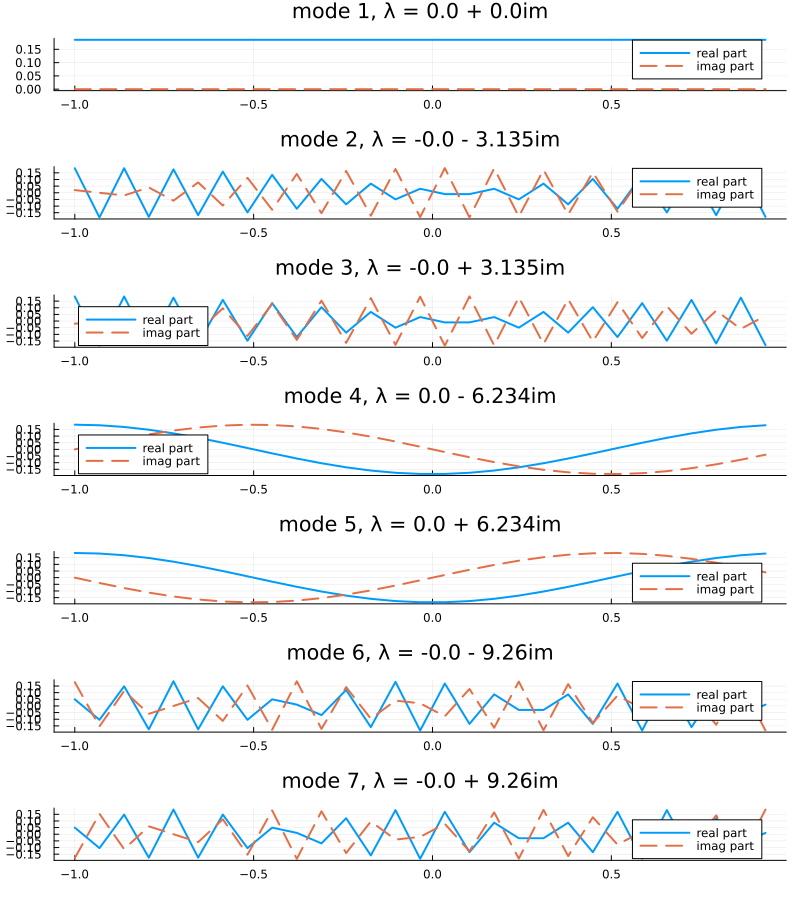

In [77]:
nmodes = 7

p = plot(layout=(nmodes,1), size=(800,900))

for j in 1:nmodes
    v = Vs[:, j]

    # phase = angle(v[findfirst(!iszero, v)])
    # v0 = v * exp(-im * phase)

    c = real.(v)
    s = imag.(v)

    # # Normalize each for display
    # if maximum(abs.(c)) > 0
    #     c ./= maximum(abs.(c))
    # end
    # if maximum(abs.(s)) > 0
    #     s ./= maximum(abs.(s))
    # end

    plot!(p[j], x[1:end-1], c, lw=2, label="real part")
    plot!(p[j], x[1:end-1], s, lw=2, ls=:dash, label="imag part")
    title!(p[j], "mode $j, λ = $(round((λs[j]),digits=3))")
end

display(p)

In [7]:
a/dx

99.99999999999991

In [8]:
maximum(abs.(imag.(λs)))

99.99999999999994

## Diffusion only, periodic BCs

In [78]:
# Set up grid
xL = -2.0
xR =  2.0
Nx = 91                      # number of points
x = range(xL, xR, length=Nx)

# Calculate cell size
dx = x[2] - x[1]

# Set diffusivity
μ = 2.0

# Allocate stiffness matrix
A = zeros(Nx - 1, Nx - 1)

# Equation: u_t = \mu u_xx, with periodic BCs
# semi-discrete: u_t(x_i) = μ / Δx^2 ( u_{i+1} - 2 u_i + u_{i-1} )

# Construct A except for first and last row
for i in 2:(Nx - 2)
    A[i, i - 1] =  μ / (dx^2)
    A[i, i    ] =  -2 * μ / (dx^2)
    A[i, i + 1] =  μ / (dx^2)
end

# Periodic BCs
A[1,    Nx-1] = μ / (dx^2)
A[1,    1]    = -2 * μ / (dx^2)
A[1,    2]    =  μ / (dx^2)

A[Nx-1, Nx-2] = μ / (dx^2)
A[Nx-1, Nx-1] = -2 * μ / (dx^2)
A[Nx-1, 1]    = μ / (dx^2)

# display(A);

# Calculate eigenvalues of A
F = eigen(A);

λ = F.values;      # eigenvalues
V = F.vectors;     # columns are eigenvectors

perm = sortperm(abs.(real.(λ)));

λs = λ[perm];
Vs = V[:, perm];
display(λs)

90-element Vector{Float64}:
    -6.325062495220319e-14
    -4.9327982238546175
    -4.932798223855977
   -19.707160798318974
   -19.707160798320157
   -44.2511085140426
   -44.25110851404356
   -78.4450657249031
   -78.44506572490401
  -122.12244290853438
  -122.12244290853518
  -175.07044827373176
  -175.0704482737328
     ⋮
 -3874.9295517262553
 -3927.877557091453
 -3927.8775570914536
 -3971.5549342750833
 -3971.5549342750837
 -4005.7488914859437
 -4005.748891485946
 -4030.2928392016665
 -4030.292839201668
 -4045.0672017761303
 -4045.067201776132
 -4049.9999999999877

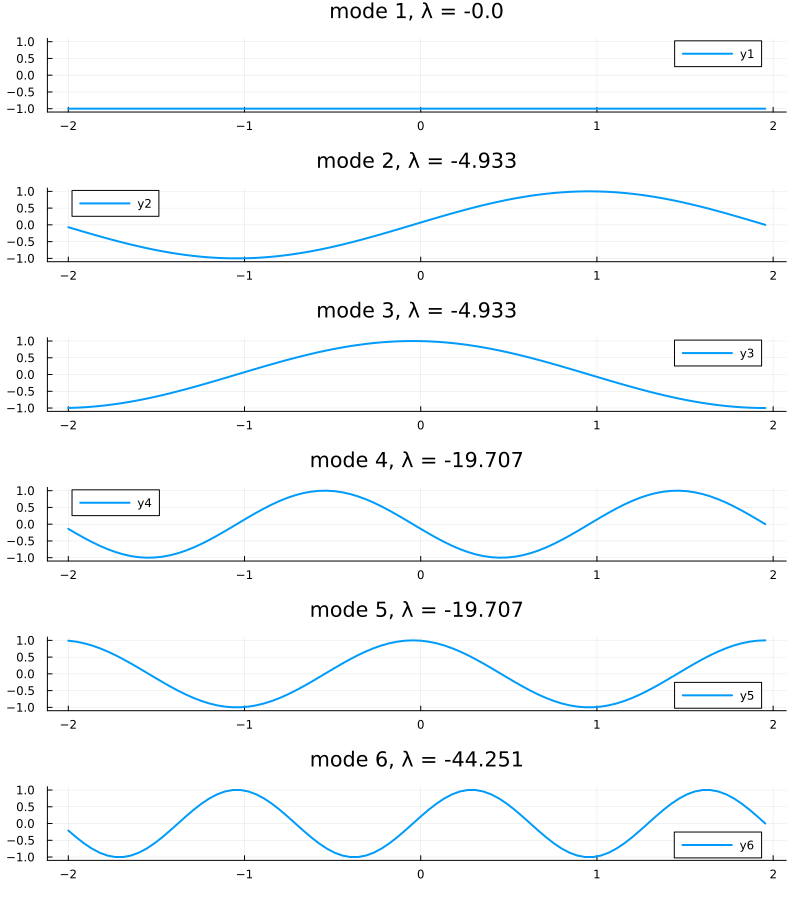

In [79]:
nmodes = 6

p = plot(layout=(nmodes,1), size=(800,900))

for j in 1:nmodes
    v = Vs[:, j]

    c = real.(v)
    s = imag.(v)

    # Normalize each for display
    if maximum(abs.(c)) > 0
        c ./= maximum(abs.(c))
    end
    if maximum(abs.(s)) > 0
        s ./= maximum(abs.(s))
    end

    plot!(p[j], x[1:end-1], c, lw=2, ylims = (-1.1, 1.1))
    title!(p[j], "mode $j, λ = $(round((λs[j]),digits=3))")
    
end

display(p)

In [26]:
minimum((real.(λ)))

-4049.9999999999877

In [27]:
4 * μ / (dx^2)

4049.999999999988